# INDAP fomento finance — review notebook (v1)

Supply opportunities for **INDAP** plus the program→action crosswalk. Loads the hand-curated supply table, validates it, renders the aggregates the review cites, then builds the mapping to the city action list (`actions_profiled.csv`).

Dataset README one level up; need `2026-06-cl-finance-opportunities`. Restart-and-run-all must pass. Charts render inline (never saved as files).

In [1]:
# Block 1 — parameters & imports (Mage-portable: paths are the only config)
%matplotlib inline
import csv, os, ast
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

SUPPLY_CSV = 'data/cl_indap_fondos_v1.csv'
MAP_CSV    = 'data/cl_indap_fondos_to_actions.csv'
ACTIONS    = '../../../../cl-ssg/cl-ssg-projects/releases/v1/data/derived/actions_profiled.csv'  # target taxonomy (102 city actions)
assert os.path.exists(SUPPLY_CSV), SUPPLY_CSV
assert os.path.exists(ACTIONS), ACTIONS
print('paths ok')

paths ok


In [2]:
# Block 2 — load the hand-curated supply table (no transformations; source has no PII)
supply = pd.read_csv(SUPPLY_CSV, dtype=str).fillna('')
print(f'{len(supply)} programs, {supply.shape[1]} cols')
supply[['program','instrument_type','recurrence','climate_relevance','gpc_sectors','status']].head(len(supply))

9 programs, 17 cols


,program,instrument_type,recurrence,climate_relevance,gpc_sectors,status
0,Transición a la Agricultura Sostenible (TAS),grant + technical_assistance,biennial-cycle,explicit,"[""afolu""]",closed
1,Sistema de Incentivos para la Sustentabilidad ...,grant (incentivo),annual,explicit,"[""afolu""]",periodic
2,Programa de Riego (Obras Menores de Riego / ri...,grant (cofinanciamiento),annual,explicit,"[""afolu""]",periodic
3,Programa de Desarrollo Local (PRODESAL),grant + technical_assistance,ongoing,climate-adjacent,"[""afolu""]",ongoing
4,Programa de Desarrollo Territorial Indígena (P...,grant + technical_assistance,ongoing,climate-adjacent,"[""afolu""]",ongoing
5,Servicio de Asesoría Técnica (SAT),technical_assistance,annual,climate-adjacent,"[""afolu""]",periodic
6,Programa de Alianzas Productivas (PAP),grant + technical_assistance,annual,indirect,"[""afolu""]",periodic
7,Programa Desarrollo de Inversiones (PDI),grant (cofinanciamiento de inversiones),annual,indirect,"[""afolu""]",periodic
8,Créditos INDAP (corto y largo plazo),loan,ongoing,indirect,"[""afolu""]",ongoing


In [3]:
# Block 3 — validate: schema, controlled vocab, completeness (assertions, not eyeballing)
REQUIRED = ['program','funder_institution','instrument_type','recurrence','climate_relevance','gpc_sectors','source_url']
for c in REQUIRED: assert c in supply.columns, f'missing col {c}'
assert supply['program'].is_unique, 'duplicate program'
assert (supply['source_url'].str.startswith('http')).all(), 'every program needs a source_url'
VOCAB_REC = {'annual','ongoing','biennial-cycle','time-boxed'}
VOCAB_CR  = {'explicit','climate-adjacent','indirect'}
bad_rec = set(supply['recurrence']) - VOCAB_REC
bad_cr  = set(supply['climate_relevance']) - VOCAB_CR
assert not bad_rec, f'unexpected recurrence values: {bad_rec}'
assert not bad_cr,  f'unexpected climate_relevance values: {bad_cr}'
print('validation passed:', len(supply), 'programs, vocab clean, all source_urls present')

validation passed: 9 programs, vocab clean, all source_urls present


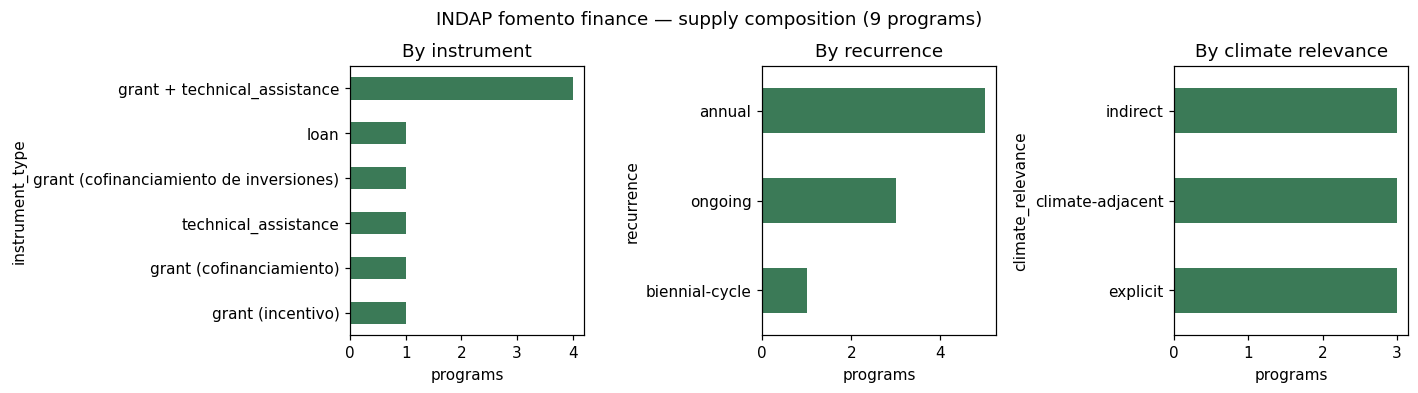

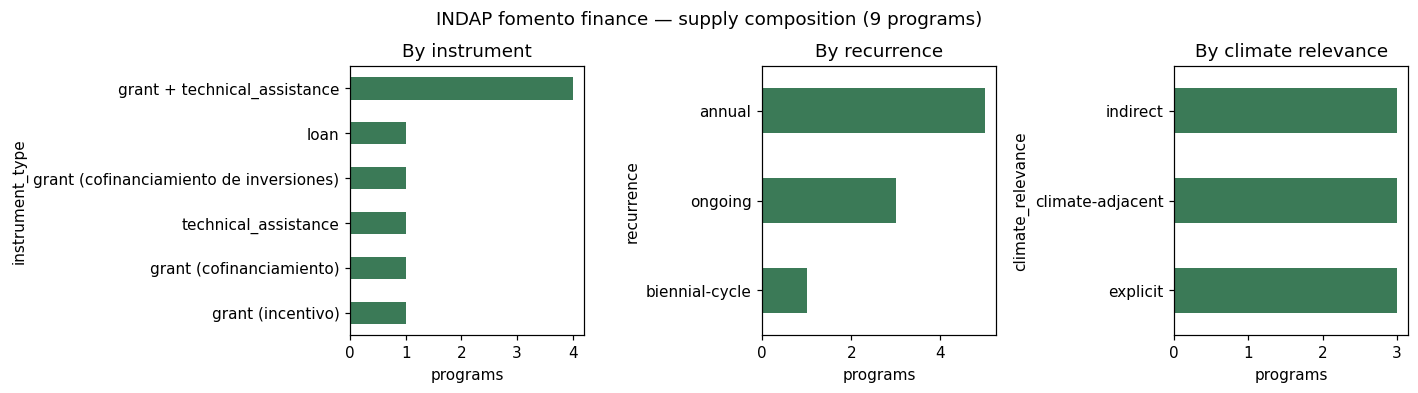

In [4]:
# Block 4 — aggregates the review cites (rendered inline; not saved as files)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, ttl in zip(axes,
        ['instrument_type','recurrence','climate_relevance'],
        ['By instrument','By recurrence','By climate relevance']):
    vc = supply[col].value_counts()
    vc.sort_values().plot.barh(ax=ax, color='#3b7a57')
    ax.set_title(ttl); ax.set_xlabel('programs')
fig.suptitle('INDAP fomento finance — supply composition ({} programs)'.format(len(supply)))
fig.tight_layout(); fig.subplots_adjust(top=0.84)
fig

In [5]:
# Block 5 — program -> action mapping (curated; link-don't-attribute; one row per pair)
# mediums/lows/none are agent drafts AWAITING human adjudication.
actions = pd.read_csv(ACTIONS)
actions['id'] = actions[actions.columns[0]]
acat = {r['id']: (str(r['action_name']).strip(), r['gpc_reference_number']) for _, r in actions.iterrows()}

PROG_META = {
    'indap_tas': ('Transición a la Agricultura Sostenible (TAS)', 'INDAP', 'afolu', 'explicit'),
    'indap_sirsds': ('SIRSD-S', 'INDAP', 'afolu', 'explicit'),
    'indap_riego': ('Programa de Riego (PROMR/PRI)', 'INDAP', 'afolu', 'explicit'),
    'indap_prodesal': ('PRODESAL', 'INDAP', 'afolu', 'climate-adjacent'),
    'indap_pdti': ('PDTI (INDAP-CONADI)', 'INDAP', 'afolu', 'climate-adjacent'),
    'indap_sat': ('Servicio de Asesoría Técnica (SAT)', 'INDAP', 'afolu', 'climate-adjacent'),
    'indap_pap': ('Programa de Alianzas Productivas (PAP)', 'INDAP', 'afolu', 'indirect'),
    'indap_pdi': ('Programa Desarrollo de Inversiones (PDI)', 'INDAP', 'afolu', 'indirect'),
    'indap_creditos': ('Créditos INDAP', 'INDAP', 'afolu', 'indirect'),
}

MAPPING = [
    ('indap_tas', 'icare_0045', 'high', "TAS's stated purpose is the transition to sustainable/agroecological farming systems — a direct match to regenerative/agroecological agriculture."),
    ('indap_tas', 'ipcc_0067', 'medium', 'TAS transition investments include soil/nutrient practices; partial overlap with crop-nutrient management.'),
    ('indap_tas', 'icare_0099', 'medium', 'TAS can lead users toward agroecological certification; instrument-adjacent (medium by convention).'),
    ('indap_sirsds', 'ipcc_0067', 'medium', "SIRSD-S funds phosphorus fertilization and chemical correction — overlaps crop-nutrient practices, but SIRSD's soil-restoration core has no exact action (taxonomy gap)."),
    ('indap_sirsds', 'icare_0045', 'medium', 'Cover-crop establishment and erosion control are regenerative-agriculture practices; partial match.'),
    ('indap_riego', '', 'none', 'No on-farm irrigation / agricultural water-efficiency action exists in the target list; closest water actions are urban supply/energy. Taxonomy gap.'),
    ('indap_prodesal', 'icare_0045', 'medium', 'Broad municipal-delivered extension with an explicit climate-adaptation/sustainable-practice mandate; delivery vehicle, not the option itself — medium.'),
    ('indap_pdti', 'icare_0045', 'medium', 'Indigenous rural-development extension that can fund sustainable practices; broad delivery vehicle — medium.'),
    ('indap_pdti', 'icare_0127', 'low', 'PDTI can support environmental/land regularization for indigenous rural properties; weak, conditional.'),
    ('indap_sat', 'icare_0045', 'medium', 'Technical-advisory instrument toward sustainable practices; medium by the instruments convention.'),
    ('indap_pap', 'icare_0132', 'medium', 'Alianzas Productivas links smallholders to buyers; overlaps short-supply-chain action where produce is agroecological.'),
    ('indap_pdi', 'icare_0101', 'low', 'PDI can co-finance on-farm machinery incl. lower-emission models; broad investment fund — low.'),
    ('indap_pdi', 'icare_0045', 'low', 'PDI can co-finance sustainable productive investments; broad and indirect — low.'),
    ('indap_creditos', '', 'none', 'Cross-cutting credit instrument financing any AFC investment; a finance lever, not a specific intervention.'),
]

rows = []
for pid, aid, conf, rat in MAPPING:
    pn, fund, sec, cr = PROG_META[pid]
    an, agpc = (acat[aid] if aid else ('', ''))
    if aid: assert aid in acat, f'unknown action {aid}'
    rows.append(dict(program_id=pid, program_name=pn, funder=fund, program_gpc_sector=sec,
                     program_climate_relevance=cr, action_id=aid, action_name=an,
                     action_gpc_ref=agpc, mapping_confidence=conf, rationale=rat))
xwalk = pd.DataFrame(rows)
xwalk[['program_id','action_id','mapping_confidence']].head(len(xwalk))

,program_id,action_id,mapping_confidence
0,indap_tas,icare_0045,high
1,indap_tas,ipcc_0067,medium
2,indap_tas,icare_0099,medium
3,indap_sirsds,ipcc_0067,medium
4,indap_sirsds,icare_0045,medium
5,indap_riego,,none
6,indap_prodesal,icare_0045,medium
7,indap_pdti,icare_0045,medium
8,indap_pdti,icare_0127,low
9,indap_sat,icare_0045,medium


wrote data/cl_indap_fondos_to_actions.csv: 14 rows | 7 programs mapped, 2 none


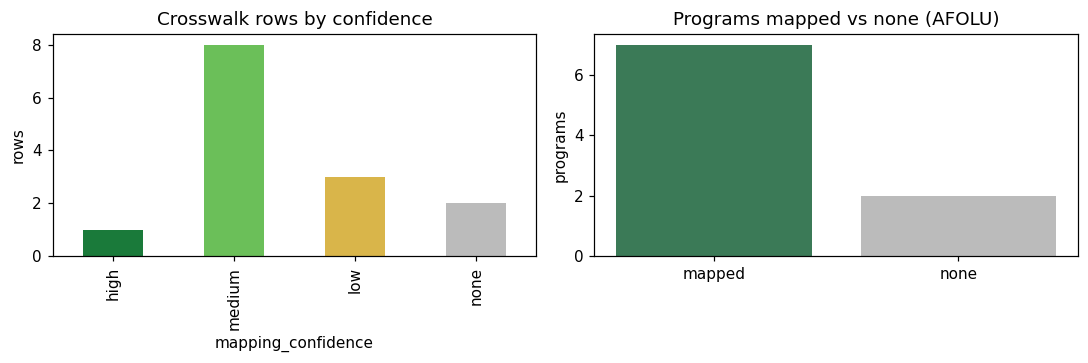

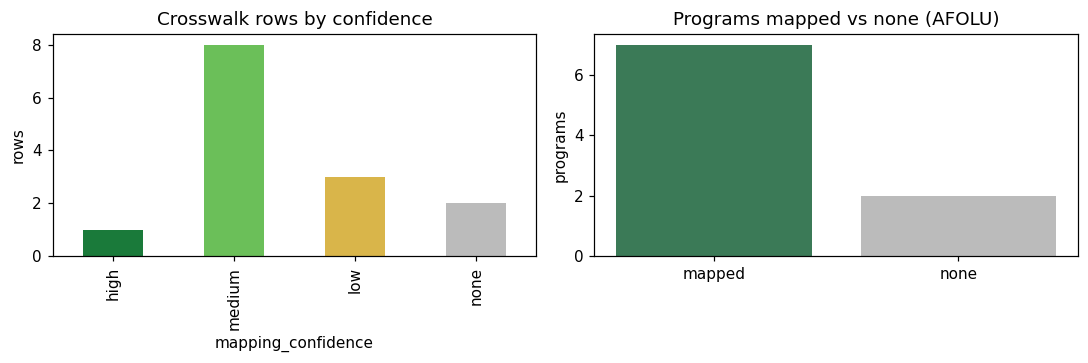

In [6]:
# Block 6 — validate mapping, export crosswalk, render coverage (both directions)
progs = set(PROG_META)
assert progs == set(xwalk['program_id']), 'every program must appear (mapped or none)'
pairs = xwalk.loc[xwalk['action_id'] != '', ['program_id','action_id']]
assert not pairs.duplicated().any(), 'duplicate (program, action) pair'
for aid in xwalk.loc[xwalk['action_id'] != '', 'action_id']:
    assert aid in acat, f'unresolved target {aid}'
xwalk.to_csv(MAP_CSV, index=False)

mapped = xwalk.loc[xwalk['mapping_confidence'] != 'none', 'program_id'].nunique()
none_n = len(progs) - mapped
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
xwalk['mapping_confidence'].value_counts().reindex(['high','medium','low','none']).fillna(0).plot.bar(
    ax=ax[0], color=['#1a7a3a','#6bbf59','#d9b54a','#bbbbbb'])
ax[0].set_title('Crosswalk rows by confidence'); ax[0].set_ylabel('rows')
ax[1].bar(['mapped','none'], [mapped, none_n], color=['#3b7a57','#bbbbbb'])
ax[1].set_title('Programs mapped vs none (AFOLU)'); ax[1].set_ylabel('programs')
fig.tight_layout()
print(f'wrote {MAP_CSV}: {len(xwalk)} rows | {mapped} programs mapped, {none_n} none')
fig

## Findings

- Supply table validates (unique programs, clean controlled vocab, every program has a `source_url`).
- The program→action crosswalk is the second committed `data/` output; quantities stay at program grain (link, don't attribute) so an award/amount on a program weights its mapped actions, never split across them.
- Coverage is reported both directions in the charts above; unreached-target and `none` reasons live in the rationale column and flow into `review.md`.
- All medium/low/none rows are agent drafts and **await human adjudication**.